### ENSIMAG – Grenoble INP – UGA - Academic year 2024-2025
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Alexandre Wendling -- `alexandre.wendling@univ-grenoble-alpes.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods (25 points)

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1 (9 points)

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

def objectif_bernoulli(n: int, p: float):
    return np.random.binomial(1, p, n)

epsilon = 2
p = 0.3


mu0 = np.array([0, 0])
mu1 = np.array([epsilon, 0])

sigma0 = np.array([
    [0.5, 0],
    [0, 0.5]
])

sigma1 = np.array([
    [0.4, 0],
    [0, 0.4]
])




def generate_dataset(N, epsilon, p):

    y = objectif_bernoulli(N, p)
    x = np.zeros((N,2))
    mu1 = np.array([epsilon, 0])
    indicatrice0 = y == 0
    indicatrice1 = y == 1

    count0 = np.sum(indicatrice0)
    count1 = np.sum(indicatrice1)


    x[indicatrice0] = np.random.multivariate_normal(mu0, sigma0, count0)
    x[indicatrice1] = np.random.multivariate_normal(mu1, sigma1, count1)
    return x, y

X_train, y_train = generate_dataset(50, epsilon, p)
X_test, y_test = generate_dataset(1000, epsilon, p)



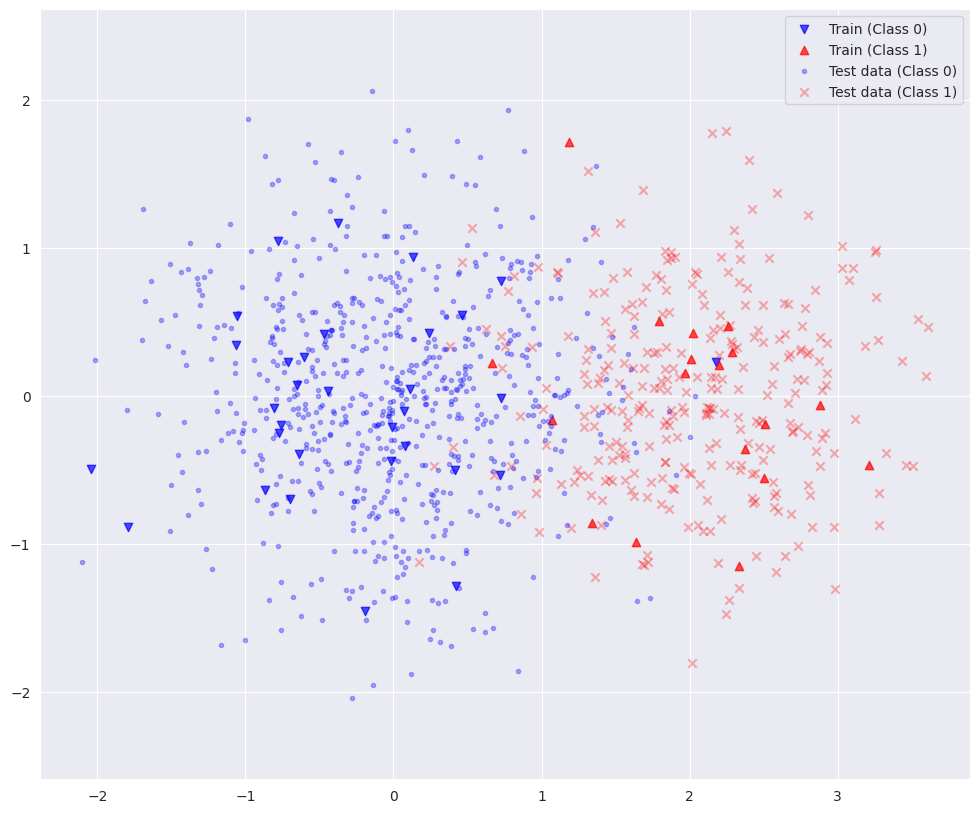

In [2]:
plt.figure(figsize=(12, 10))

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='blue', marker='v', label='Train (Class 0)', alpha=0.7 )

plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], color='red', marker='^', label='Train (Class 1)', alpha=0.7 )

# Test Point*
# CLass 0
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color='blue', marker='.', label='Test data (Class 0)', alpha=0.3 )


plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='red', marker='x', label='Test data (Class 1)', alpha=0.3 )

plt.axis('equal')
plt.legend()
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

Because $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$ are not necessarily equal, we have a different expression for the boundary:

First the Optimal Bayes classifier is writen by definition in terms of ratio :
$$\begin{equation}
  f(x) =
    \begin{cases}
      1 & \text{if $1 > \frac{\text{Prob}(Y=0 | x)}{\text{Prob}(Y=1|x)} $ }\\
      0 & \text{otherwise}
    \end{cases}
\end{equation}$$
With the boundary defined as $\mathcal{R} = \{x \in \mathbb{R}^{2} | \frac{\text{Prob}(x| Y = 0)}{\text{Prob}(x | Y = 1)} = \frac{p}{1-p}\}$

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [3]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import multivariate_normal

class Bayes_classifier(BaseEstimator, ClassifierMixin):

    def __init__(self,mu0, mu1, sigma0, sigma1, p):
        self.mu0 = mu0
        self.mu1 = mu1
        self.sigma0 = sigma0
        self.sigma1 = sigma1
        self.p = p

    def fit(self, X, y):
        assert(X.shape[0] == y.shape[0])
        """
        Because we know the parameters of our setup, we don't need to fit anything
        """
        return self


    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        """
        Let's predict the probability for each class
        :param X:
        :return: np.array
        """

        probs = np.zeros((X.shape[0], 2))

        for i, x in enumerate(X):
            """With bayes rules we can deduce the probability of each class, P(Y=1|x0)*P(x0) = P(x0|Y=1)*P(Y=1)"""
            px_given_y0 = multivariate_normal.pdf(x, self.mu0, self.sigma0)
            px_given_y1 = multivariate_normal.pdf(x, self.mu1, self.sigma1)

            py0 = 1 - self.p
            py1 = self.p

            py0_given_x = py0 * px_given_y0
            py1_given_x = py1 * px_given_y1

            # let's normalize to have probability
            total = py0_given_x + py1_given_x
            probs[i, 0] = py0_given_x/total
            probs[i, 1] = py1_given_x/total
        return probs

    def predict_log_proba(self, X):
        pass

    def decision_function(self, X):
        pass








Bayes error for D_test : 0.0644


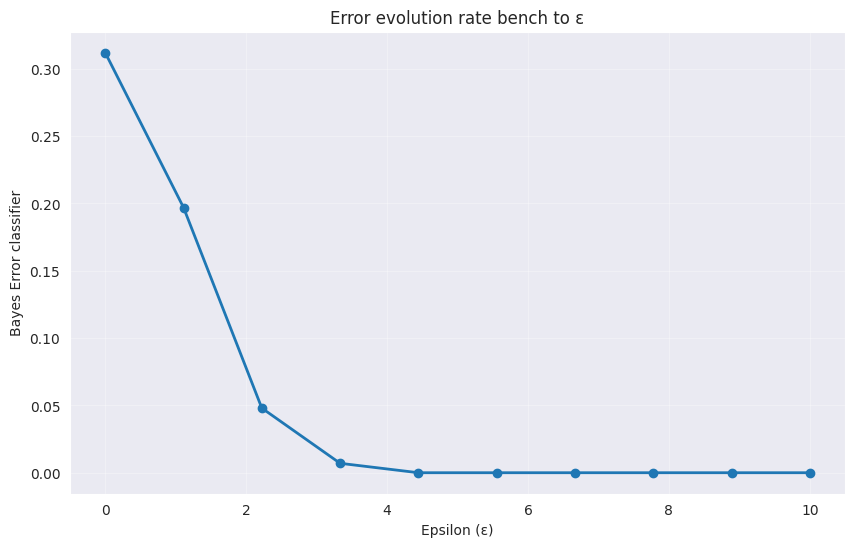

In [4]:

def compute_error_rate(y_true, y_pred):
    return np.mean(y_true != y_pred)

X_test_c, y_test_c = generate_dataset(10000, epsilon, p)
bayes_clf = Bayes_classifier(mu0, mu1, sigma0, sigma1, p)
y_pred_bayes = bayes_clf.predict(X_test_c)
bayes_error = compute_error_rate(y_test_c, y_pred_bayes)
print(f"Bayes error for D_test : {bayes_error}")

epsilons = np.linspace(0, 10, 10)
error_rates = []

for eps in epsilons:
    mu1_eps = np.array([eps, 0])

    X_large_test, y_large_test = generate_dataset(1000, eps, p)
    X_train, y_train = generate_dataset(500, epsilon, p)

    bayes_clf = Bayes_classifier(mu0, mu1_eps, sigma0, sigma1, p)
    bayes_clf.fit(X_large_test, y_large_test)
    y_pred = bayes_clf.predict(X_large_test)


    error = compute_error_rate(y_large_test, y_pred)
    error_rates.append(error)

plt.figure(figsize=(10, 6))
plt.plot(epsilons, error_rates, 'o-', linewidth=2)
plt.xlabel('Epsilon (ε)')
plt.ylabel('Bayes Error classifier')
plt.title('Error evolution rate bench to ε')
plt.grid(True, alpha=0.3)
plt.show()

We initially predicted that as ε increases, the error would decrease because the classes become better separated.
Indeed, when testing we confirmed that the error tends toward 0 as ε increases, which aligns with our initial intuition.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

Based on the structure of the model generating the datasets, Quadratic Discriminant Analysis (QDA) is clearly the most adequate classifier among those presented in our lectures.

The data generation process follows these specific assumptions:
- Each class (Y=0 and Y=1) follows a multivariate normal distribution
- The classes have different covariance matrices

QDA is specifically designed for this exact scenario as it:
1. Assumes that each class follows a multivariate normal distribution
2. Allows for different covariance matrices between classes
3. Directly models the conditional distributions p(x|Y=k) which makes it optimal when these distributions are truly Gaussian

In contrast, other classifiers would be less suitable:
- LDA assumes equal covariance matrices, which is violated in this case
- Logistic regression makes no distributional assumptions but imposes a linear decision boundary, which may not be optimal for Gaussian data with unequal covariances
- k-NN is non-parametric and doesn't leverage the known Gaussian structure of the data
- Naive Bayes would incorrectly assume independence between features (here we have independance, so it can be a good choice too)

Since QDA's assumptions perfectly match the data generation process, it would theoretically achieve the Bayes error rate for this problem.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.


In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression

epsilon = 2

X_test_c, y_test_c = generate_dataset(10000, epsilon, p)
bayes_clf = Bayes_classifier(mu0, np.array([epsilon, 0]), sigma0, sigma1, p)
y_pred_bayes = bayes_clf.predict(X_test_c)
bayes_error = compute_error_rate(y_test_c, y_pred_bayes)
print(f"Bayes error for D_test : {bayes_error}")

classifier_LDA = LDA()
classifier_QDA = QDA()
classifier_logistic = LogisticRegression()

classifier_LDA.fit(X_train, y_train)
classifier_QDA.fit(X_train, y_train)
classifier_logistic.fit(X_train, y_train)

y_pred_LDA = classifier_LDA.predict(X_test)
y_pred_QDA = classifier_QDA.predict(X_test)
y_pred_logistic = classifier_logistic.predict(X_test)


error_LDA = compute_error_rate(y_test, y_pred_LDA)
error_QDA = compute_error_rate(y_test, y_pred_QDA)
error_logistic = compute_error_rate(y_test, y_pred_logistic)



print(f"LDA Error : {error_LDA}, with Bayes: {error_LDA - bayes_error}")
print(f"QDA Error: {error_QDA}, with Bayes: {error_QDA - bayes_error}")
print(f"Logistic Error : {error_logistic}, with Bayes: {error_logistic - bayes_error}")

Bayes error for D_test : 0.064
LDA Error : 0.065, with Bayes: 0.0010000000000000009
QDA Error: 0.061, with Bayes: -0.0030000000000000027
Logistic Error : 0.059, with Bayes: -0.0050000000000000044


The bayes error rate is high for small epsilon, but when epsilon is greater than 3, it's practically equal to 0.

Because the bayes classifier is the optimal classifier (the one that minimize the probability of a point not belonging to his true class), we expected that his error will be less, but as we saw at question c) the error for small epsilon is quite high du to the homogenous set of points from both classes. But whenever epsilon is greater than 3, we can see that it's the optimal.

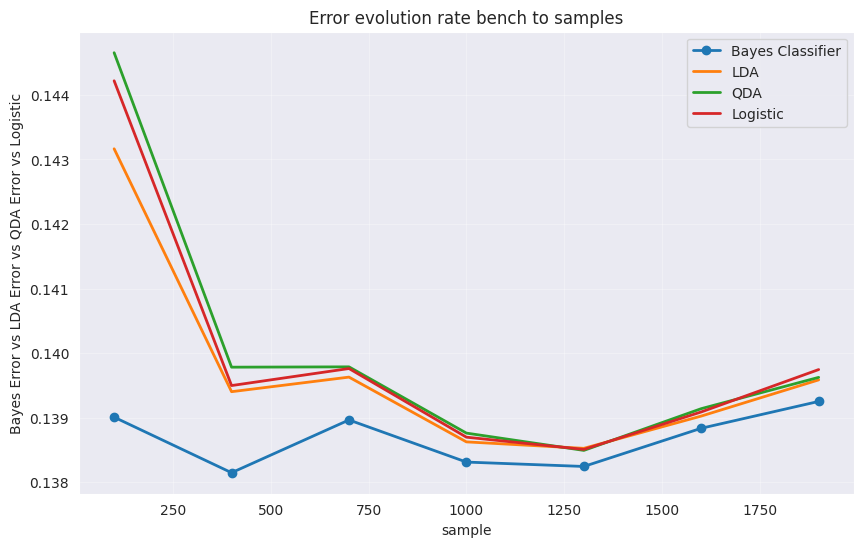

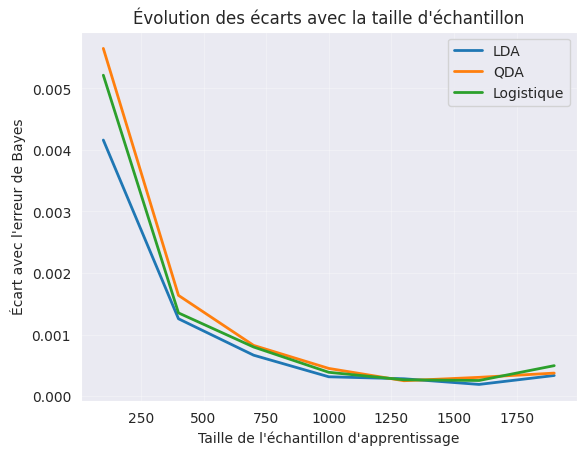

In [48]:




samples = np.arange(100, 2000, 300)
error_rates_samples = []
error_rates_LDA_samples = []
error_rates_QDA_samples = []
error_rates_logistic_samples = []
for sample in samples:
    errors_bayes = []
    errors_lda = []
    errors_qda = []
    errors_logistic = []
    for _ in range(100):

        mu1_eps = np.array([epsilon, 0])

        X_large_test, y_large_test = generate_dataset(10000, epsilon, p)
        X_train, y_train = generate_dataset(sample, epsilon, p)

        bayes_clf = Bayes_classifier(mu0, mu1_eps, sigma0, sigma1, p)
        bayes_clf.fit(X_large_test, y_large_test)
        y_pred = bayes_clf.predict(X_large_test)

        classifier_LDA = LDA()
        classifier_QDA = QDA()
        classifier_logistic = LogisticRegression()
        classifier_LDA.fit(X_train, y_train)
        classifier_QDA.fit(X_train, y_train)
        classifier_logistic.fit(X_train, y_train)
        y_pred_LDA = classifier_LDA.predict(X_large_test)
        y_pred_QDA = classifier_QDA.predict(X_large_test)
        y_pred_logistic = classifier_logistic.predict(X_large_test)


        error = compute_error_rate(y_large_test, y_pred)
        error_LDA = compute_error_rate(y_large_test, y_pred_LDA)
        error_QDA = compute_error_rate(y_large_test, y_pred_QDA)
        error_logistic = compute_error_rate(y_large_test, y_pred_logistic)

        errors_bayes.append(error)
        errors_lda.append(error_LDA)
        errors_qda.append(error_QDA)
        errors_logistic.append(error_logistic)

    error_rates_samples.append(np.mean(errors_bayes))
    error_rates_LDA_samples.append(np.mean(errors_lda))
    error_rates_QDA_samples.append(np.mean(errors_qda))
    error_rates_logistic_samples.append(np.mean(errors_logistic))


plt.figure(figsize=(10, 6))
plt.plot(samples, error_rates_samples, 'o-', linewidth=2)
plt.plot(samples, error_rates_LDA_samples, '-', linewidth=2)
plt.plot(samples, error_rates_QDA_samples, '-', linewidth=2)
plt.plot(samples, error_rates_logistic_samples, '-', linewidth=2)
plt.xlabel('sample')
plt.ylabel('Bayes Error vs LDA Error vs QDA Error vs Logistic')
plt.title('Error evolution rate bench to samples')
plt.legend(['Bayes Classifier','LDA', 'QDA', 'Logistic'])
plt.grid(True, alpha=0.3)
plt.show()

gaps_lda = np.array(error_rates_LDA_samples) - np.array(error_rates_samples)
gaps_qda = np.array(error_rates_QDA_samples) - np.array(error_rates_samples)
gaps_logistic = np.array(error_rates_logistic_samples) - np.array(error_rates_samples)

plt.plot(samples, gaps_lda, '-', linewidth=2)
plt.plot(samples, gaps_qda, '-', linewidth=2)
plt.plot(samples, gaps_logistic, '-', linewidth=2)
plt.xlabel('Taille de l\'échantillon d\'apprentissage')
plt.ylabel('Écart avec l\'erreur de Bayes')
plt.title('Évolution des écarts avec la taille d\'échantillon')
plt.legend(['LDA', 'QDA', 'Logistique'])
plt.grid(True, alpha=0.3)
plt.show()



- Theoretically, the gap between the Bayes error rate and the error rates of the classifiers decreases as the number of training samples increases. This is consistent with statistical learning theory, which predicts that with more data, our estimators become more accurate.

- Empirically, we observe this decrease in error rates until approximately 1600 samples, after which there is a slight increase that is likely due to residual variance in our sampling process. Overall, the trend confirms our theoretical understanding that more training data leads to better approximation of the optimal classifier.

- QDA comes closest to the Bayes classifier performance because its assumptions perfectly match the data-generating model (different covariance matrices for each class). This demonstrates that when a classifier's assumptions align with the true data distribution, it can achieve near-optimal performance with sufficient training data.

These findings highlight the importance of both the number of training samples and the alignment between classifier assumptions and actual data characteristics in determining classification performance.




**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

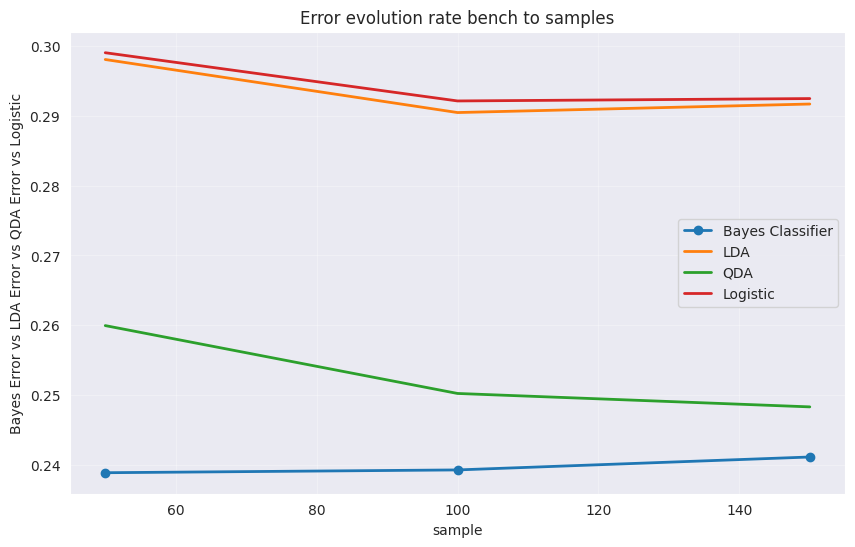

In [43]:



epsilon_prime = 0.5
p_prime = 0.7
samples = np.arange(50, 200, 50)
error_rates_samples = []
error_rates_LDA_samples = []
error_rates_QDA_samples = []
error_rates_logistic_samples = []
for sample in samples:
    errors_bayes = []
    errors_lda = []
    errors_qda = []
    errors_logistic = []
    for _ in range(100):

        mu1_eps = np.array([epsilon_prime, 0])

        X_large_test, y_large_test = generate_dataset(1000, epsilon_prime, p_prime)
        X_train, y_train = generate_dataset(sample, epsilon_prime, p_prime)

        bayes_clf = Bayes_classifier(mu0, mu1_eps, sigma0, sigma1, p_prime)
        bayes_clf.fit(X_large_test, y_large_test)
        y_pred = bayes_clf.predict(X_large_test)

        classifier_LDA = LDA()
        classifier_QDA = QDA()
        classifier_logistic = LogisticRegression()
        classifier_LDA.fit(X_train, y_train)
        classifier_QDA.fit(X_train, y_train)
        classifier_logistic.fit(X_train, y_train)
        y_pred_LDA = classifier_LDA.predict(X_large_test)
        y_pred_QDA = classifier_QDA.predict(X_large_test)
        y_pred_logistic = classifier_logistic.predict(X_large_test)


        error = compute_error_rate(y_large_test, y_pred)
        error_LDA = compute_error_rate(y_large_test, y_pred_LDA)
        error_QDA = compute_error_rate(y_large_test, y_pred_QDA)
        error_logistic = compute_error_rate(y_large_test, y_pred_logistic)

        errors_bayes.append(error)
        errors_lda.append(error_LDA)
        errors_qda.append(error_QDA)
        errors_logistic.append(error_logistic)

    error_rates_samples.append(np.mean(errors_bayes))
    error_rates_LDA_samples.append(np.mean(errors_lda))
    error_rates_QDA_samples.append(np.mean(errors_qda))
    error_rates_logistic_samples.append(np.mean(errors_logistic))


plt.figure(figsize=(10, 6))
plt.plot(samples, error_rates_samples, 'o-', linewidth=2)
plt.plot(samples, error_rates_LDA_samples, '-', linewidth=2)
plt.plot(samples, error_rates_QDA_samples, '-', linewidth=2)
plt.plot(samples, error_rates_logistic_samples, '-', linewidth=2)
plt.xlabel('sample')
plt.ylabel('Bayes Error vs LDA Error vs QDA Error vs Logistic')
plt.title('Error evolution rate bench to samples')
plt.legend(['Bayes Classifier','LDA', 'QDA', 'Logistic'])
plt.grid(True, alpha=0.3)
plt.show()


The results demonstrate that when facing a significant distribution shift between training and testing data, simpler models (LDA, logistic regression) exhibit better robustness than QDA. Although QDA is theoretically optimal when the distribution remains constant, its greater flexibility actually makes it more vulnerable to distribution changes. This illustrates the classic bias-variance tradeoff: more complex models can better fit specific distributions but may generalize poorly when confronted with new data from different distributions.

## ▶️ Part 2 (8 points)

In this part, we will consider a simulated benchmark similar to that from [Section 4.5.2 in James et al](https://www.statlearning.com/) presented and discussed in class. Our benchmark will compare the performance of four classifiers under three different scenarios.

### -- Scenario 1
The observations for this scenario are generated as per:

$$
\{(\mathbf{x}_i, y_i)\}_{i = 1}^{2N} = \{(\mathbf{x}_i, 0)\}_{i = 1}^{N} \cup \{(\mathbf{x}_i, 1)\}_{i = 1}^{N}
$$
with
$$
\mathbf{x}_i | y_i = 0 \sim \mathcal{N}(\mathbf{\mu}_0, \mathbf{\Sigma}_0) \quad \text{with} \quad \mathbf{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_0 = \left[\begin{array}{cc}1 & 0 \\ 0 & 2\end{array}\right]
$$
and
$$
\mathbf{x}_i | y_i = 1 \sim \mathcal{N}(\mathbf{\mu}_1, \mathbf{\Sigma}_1) \quad \text{with} \quad \mathbf{\mu}_1 = \left[\begin{array}{c}1 \\ 1\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_1 = \left[\begin{array}{cc}1 & 0 \\ 0 & 2\end{array}\right]~.
$$

The training set always have $N=20$ and the test set $N=5000$. 

**(a)** Using `sklearn`, compare the performances of LDA, logistic regression, Gaussian naive Bayes, and QDA in this scenario. For this, you should generate 100 pairs of training-test datasets and evaluate the test errors for each of the classifiers. Use `matplotlib.pyplot.boxplot` to display the results for each of the classifiers along the different realizations. Explain the differences of the performances in terms of the assumptions of each classifier and the structure of the data generating mechanism.

In [44]:
from sklearn.naive_bayes import GaussianNB

n_train = 20
n_test = 5000




In [45]:

mu0 = np.array([0, 0])
mu1 = np.array([1, 1])

sigma0 = np.array([
    [1, 0],
    [0, 2]
])

sigma1 = np.copy(sigma0)



In [46]:
def generate_dataset_part2(N, mu01, mu10, sigma01, sigma10):

    y0 = np.array([0]*N)
    y1 = np.array([1]*N)
    x0 = np.random.multivariate_normal(mu01, sigma01, N)
    x1 = np.random.multivariate_normal(mu10, sigma10, N)

    return np.vstack((x0, x1)), np.concatenate((y0, y1))




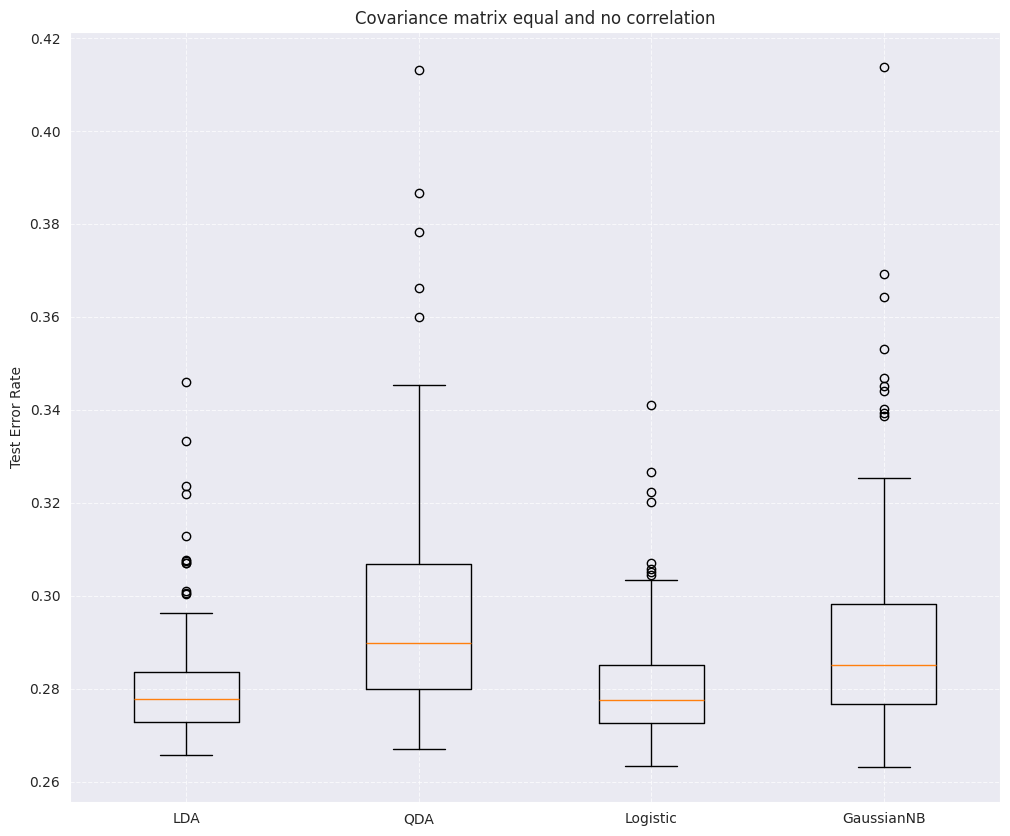

In [47]:
error_rates_LDA = []
error_rates_QDA = []
error_rates_logistic = []
error_rates_gaussian = []

for _ in range(100):
    X_train, y_train = generate_dataset_part2(n_train, mu0, mu1, sigma0, sigma1)
    X_test, y_test = generate_dataset_part2(n_test, mu0, mu1, sigma0, sigma1)

    lda = LDA()
    qda = QDA()
    logistic = LogisticRegression()
    gaussianNB = GaussianNB()

    lda.fit(X_train, y_train)
    qda.fit(X_train, y_train)
    logistic.fit(X_train, y_train)
    gaussianNB.fit(X_train, y_train)

    y_pred_lda = lda.predict(X_test)
    y_pred_qda = qda.predict(X_test)
    y_pred_logistic = logistic.predict(X_test)
    y_pred_gaussian = gaussianNB.predict(X_test)

    error_lda = compute_error_rate(y_test, y_pred_lda)
    error_qda = compute_error_rate(y_test, y_pred_qda)
    error_logistic = compute_error_rate(y_test, y_pred_logistic)
    error_gaussian = compute_error_rate(y_test, y_pred_gaussian)

    error_rates_LDA.append(error_lda)
    error_rates_QDA.append(error_qda)
    error_rates_logistic.append(error_logistic)
    error_rates_gaussian.append(error_gaussian)



errors = {
    'LDA': error_rates_LDA,
    'QDA': error_rates_QDA,
    'Logistic': error_rates_logistic,
    'GaussianNB': error_rates_gaussian
}

plt.figure(figsize=(12, 10))
plt.title("Covariance matrix equal and no correlation")
plt.boxplot([errors[key] for key in errors.keys() ], tick_labels=errors.keys())
plt.ylabel("Test Error Rate")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()





Based on the results from scenario 1, we observe that LDA, QDA, and logistic regression show relatively similar performance, with a slight advantage for QDA, while Gaussian Naive Bayes performs somewhat worse.
These results can be explained by examining the underlying assumptions of each classifier and how they align with our data structure:

- LDA: Performs well because the covariance matrices are identical between classes, which perfectly matches one of its fundamental assumptions. The linear decision boundary is also appropriate for separating the two classes in this scenario.
- QDA: Although more flexible than necessary (capable of modeling different covariance matrices), it performs well because it correctly learns the data structure. Its additional flexibility does not lead to significant overfitting with our sample size.
- Logistic Regression: Its discriminative approach allows it to adapt correctly to the linear boundary without making assumptions about the data distribution.
- Gaussian Naive Bayes: Its slightly inferior performance can be explained by its assumption of independence between variables. Although this assumption is respected in this scenario (the covariance matrix is diagonal), it does not account for the different variances in each dimension (1 vs 2), which introduces bias in the estimation.

The variance in performance across different realizations is relatively low, indicating stability of the classifiers in this simple scenario.

### -- Scenario 2
The observations for this scenario are generated as per:

$$
\{(\mathbf{x}_i, y_i)\}_{i = 1}^{2N} = \{(\mathbf{x}_i, 0)\}_{i = 1}^{N} \cup \{(\mathbf{x}_i, 1)\}_{i = 1}^{N}
$$
with
$$
\mathbf{x}_i | y_i = 0 \sim \mathcal{N}(\mathbf{\mu}_0, \mathbf{\Sigma}_0) \quad \text{with} \quad \mathbf{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_0 = \left[\begin{array}{cc}1 & -0.7 \\ -0.7 & 2\end{array}\right]
$$
and
$$
\mathbf{x}_i | y_i = 1 \sim \mathcal{N}(\mathbf{\mu}_1, \mathbf{\Sigma}_1) \quad \text{with} \quad \mathbf{\mu}_1 = \left[\begin{array}{c}1 \\ 1\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_1 = \left[\begin{array}{cc}1 & -0.7 \\ -0.7 & 2\end{array}\right]~.
$$

The training set always have $N=20$ and the test set $N=5000$. 

**(b)** Perform the same comparison as done for Scenario 1.


In [12]:

mu0 = np.array([0, 0])
mu1 = np.array([1, 1])

sigma0 = np.array([
    [1, -0.7],
    [-0.7, 2]
])

sigma1 = np.copy(sigma0)



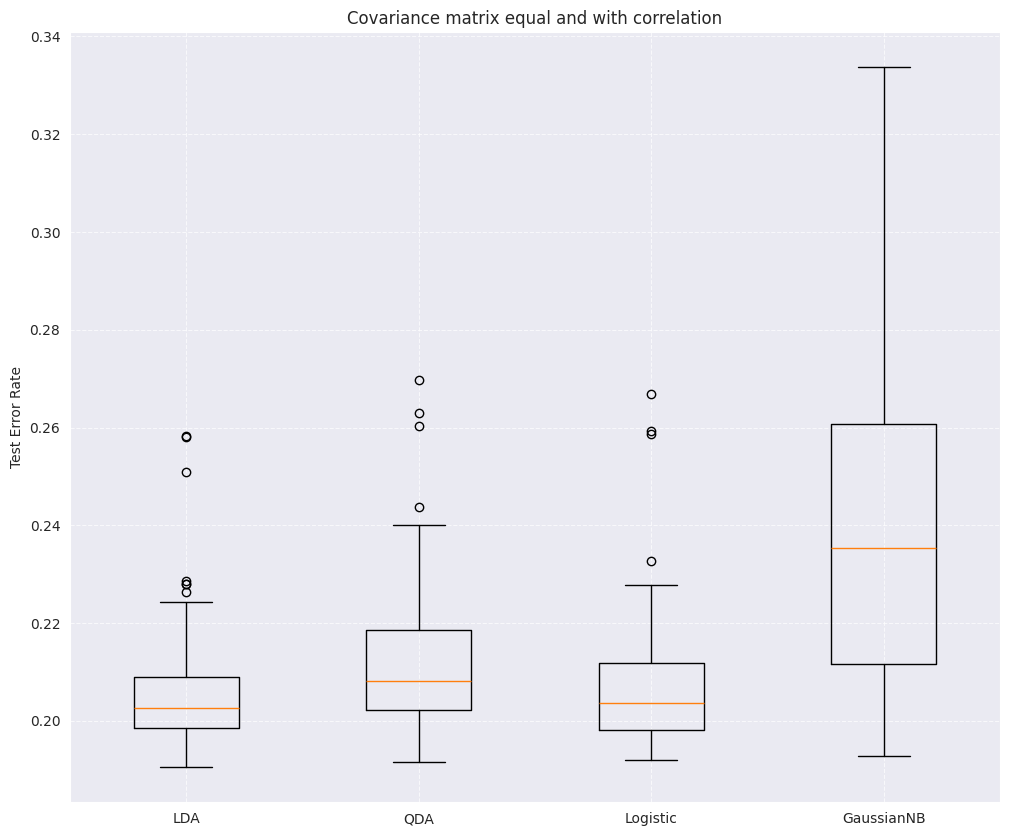

In [13]:
error_rates_LDA = []
error_rates_QDA = []
error_rates_logistic = []
error_rates_gaussian = []

for _ in range(100):
    X_train, y_train = generate_dataset_part2(n_train, mu0, mu1, sigma0, sigma1)
    X_test, y_test = generate_dataset_part2(n_test, mu0, mu1, sigma0, sigma1)

    lda = LDA()
    qda = QDA()
    logistic = LogisticRegression()
    gaussianNB = GaussianNB()

    lda.fit(X_train, y_train)
    qda.fit(X_train, y_train)
    logistic.fit(X_train, y_train)
    gaussianNB.fit(X_train, y_train)

    y_pred_lda = lda.predict(X_test)
    y_pred_qda = qda.predict(X_test)
    y_pred_logistic = logistic.predict(X_test)
    y_pred_gaussian = gaussianNB.predict(X_test)

    error_lda = compute_error_rate(y_test, y_pred_lda)
    error_qda = compute_error_rate(y_test, y_pred_qda)
    error_logistic = compute_error_rate(y_test, y_pred_logistic)
    error_gaussian = compute_error_rate(y_test, y_pred_gaussian)

    error_rates_LDA.append(error_lda)
    error_rates_QDA.append(error_qda)
    error_rates_logistic.append(error_logistic)
    error_rates_gaussian.append(error_gaussian)



errors = {
    'LDA': error_rates_LDA,
    'QDA': error_rates_QDA,
    'Logistic': error_rates_logistic,
    'GaussianNB': error_rates_gaussian
}

plt.figure(figsize=(12, 10))
plt.title("Covariance matrix equal and with correlation")
plt.boxplot([errors[key] for key in errors.keys() ], tick_labels=errors.keys())
plt.ylabel("Test Error Rate")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()





In scenario 2, we introduce a negative correlation (-0.7) between variables while maintaining identical covariance matrices between classes. The analysis of the results shows:

- LDA: Maintains good performance because the assumption of equal covariance matrices is still respected. Its ability to model correlation between variables allows it to adapt correctly to the modified data structure.
- QDA: Also performs very well for the same reasons as LDA, with slight additional flexibility that does not hinder its performance.
- Logistic Regression: Its performance decreases slightly compared to scenario 1. The presence of correlation can make the optimal decision boundary non-linear, which challenges the linearity assumption of logistic regression.
- Gaussian Naive Bayes: Shows a significant degradation in performance because its assumption of conditional independence of variables is now violated by the presence of strong correlation. This violation directly affects its ability to correctly model the data distribution.

The variance in performance is slightly higher than in scenario 1, suggesting that the introduction of correlation makes learning more sensitive to the particularities of the training sample.

### -- Scenario 3
The observations for this scenario are generated as per:

$$
\{(\mathbf{x}_i, y_i)\}_{i = 1}^{2N} = \{(\mathbf{x}_i, 0)\}_{i = 1}^{N} \cup \{(\mathbf{x}_i, 1)\}_{i = 1}^{N}
$$
with
$$
\mathbf{x}_i | y_i = 0 \sim \mathcal{N}(\mathbf{\mu}_0, \mathbf{\Sigma}_0) \quad \text{with} \quad \mathbf{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_0 = \left[\begin{array}{cc}1 & -0.7 \\ -0.7 & 2\end{array}\right]
$$
and
$$
\mathbf{x}_i | y_i = 1 \sim \mathcal{N}(\mathbf{\mu}_1, \mathbf{\Sigma}_1) \quad \text{with} \quad \mathbf{\mu}_1 = \left[\begin{array}{c}1 \\ 1\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_1 = \left[\begin{array}{cc}1 & +0.7 \\ +0.7 & 2\end{array}\right]~.
$$

The training set always have $N=20$ and the test set $N=5000$. 

**(c)** Perform the same comparison as done for Scenarios 1 and 2.

In [14]:

mu0 = np.array([0, 0])
mu1 = np.array([1, 1])

sigma0 = np.array([
    [1, -0.7],
    [-0.7, 2]
])

sigma1 = np.array([
    [1, 0.7],
    [0.7, 2]
])



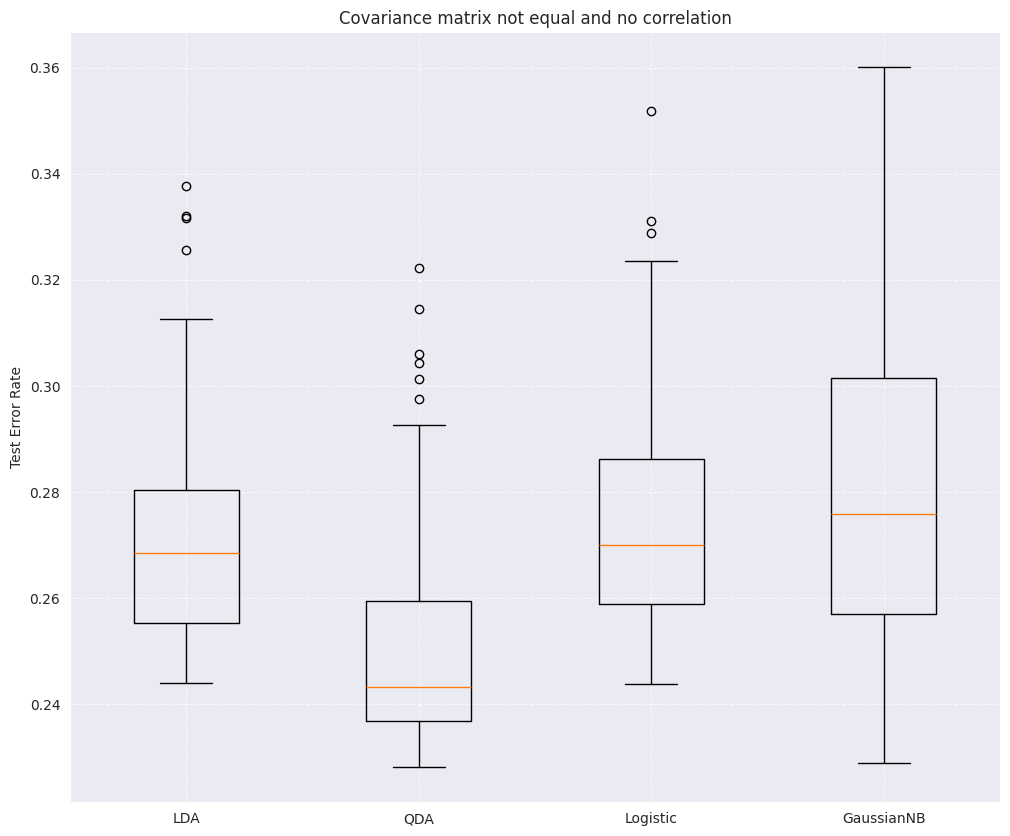

In [15]:
error_rates_LDA = []
error_rates_QDA = []
error_rates_logistic = []
error_rates_gaussian = []

for _ in range(100):
    X_train, y_train = generate_dataset_part2(n_train, mu0, mu1, sigma0, sigma1)
    X_test, y_test = generate_dataset_part2(n_test, mu0, mu1, sigma0, sigma1)

    lda = LDA()
    qda = QDA()
    logistic = LogisticRegression()
    gaussianNB = GaussianNB()

    lda.fit(X_train, y_train)
    qda.fit(X_train, y_train)
    logistic.fit(X_train, y_train)
    gaussianNB.fit(X_train, y_train)

    y_pred_lda = lda.predict(X_test)
    y_pred_qda = qda.predict(X_test)
    y_pred_logistic = logistic.predict(X_test)
    y_pred_gaussian = gaussianNB.predict(X_test)

    error_lda = compute_error_rate(y_test, y_pred_lda)
    error_qda = compute_error_rate(y_test, y_pred_qda)
    error_logistic = compute_error_rate(y_test, y_pred_logistic)
    error_gaussian = compute_error_rate(y_test, y_pred_gaussian)

    error_rates_LDA.append(error_lda)
    error_rates_QDA.append(error_qda)
    error_rates_logistic.append(error_logistic)
    error_rates_gaussian.append(error_gaussian)



errors = {
    'LDA': error_rates_LDA,
    'QDA': error_rates_QDA,
    'Logistic': error_rates_logistic,
    'GaussianNB': error_rates_gaussian
}

plt.figure(figsize=(12, 10))
plt.title("Covariance matrix not equal and no correlation")
plt.boxplot([errors[key] for key in errors.keys() ], tick_labels=errors.keys())
plt.ylabel("Test Error Rate")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()





Scenario 3 presents the most complex case: different covariance matrices between classes with correlations of opposite signs. The results show:

- QDA: Clearly achieves the best performance because it is the only classifier capable of correctly modeling different covariance matrices between classes. Its fundamental assumption exactly matches the data structure.
- LDA: Its performance degrades compared to previous scenarios because its assumption of equal covariance matrices is violated. It is forced to learn a common covariance matrix that does not faithfully represent the actual data structure.
- Logistic Regression: Maintains performance comparable to LDA, but inferior to QDA. The optimal decision boundary is certainly non-linear in this scenario, which limits the effectiveness of its linear approach.
- Gaussian Naive Bayes: Continues to have the worst performance, suffering both from its inability to model correlations and its assumption of homogeneous variances between classes.

The variance in performance is higher than in previous scenarios, reflecting the increased difficulty of learning the complex data structure with a limited sample.

These three scenarios perfectly illustrate the bias-variance tradeoff in statistical learning:

- When a model's assumptions exactly match the data structure (like QDA in scenario 3), it achieves optimal performance.
- Simpler models (like LDA or logistic regression) can work well even when their assumptions are slightly violated, as they benefit from reduced variance.
- The conditional independence assumption of Naive Bayes proves particularly restrictive when correlations exist between variables.

These results confirm the importance of choosing a classifier whose assumptions align with the underlying structure of the data, while taking into account model complexity and available sample size.


## ▶️ Part 3: Real data (8 points)

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

## Without Skrub







In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_union
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.ensemble import RandomForestRegressor as RFR, HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier as RFC

In [17]:
df_original = pd.read_csv("titanic/train.csv")
df_modified = df_original.copy()
df_modified.drop("Name", axis=1, inplace=True)
df_modified.drop("Ticket", axis=1, inplace=True)
df_modified.drop("Cabin", axis=1, inplace=True)
df_modified.drop("PassengerId", axis=1, inplace=True)

# Let's have a look on the data
print("Head of the training set\n")
display(df_modified.head())
print("\n")
print("Info on the training set\n")
display(df_modified.info())
print("\n")
print("Description in general of the training set\n")
display(df_modified.describe())


Head of the training set



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S




Info on the training set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


None



Description in general of the training set



,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
df_modified["Sex"] = df_modified["Sex"].astype("category")

df_modified['FamilySize'] = df_modified['SibSp'] + df_modified['Parch'] + 1


df_modified['IsAlone'] = (df_modified['FamilySize'] == 1).astype(int)


df_modified['FamilyCategory'] = pd.cut(
    df_modified['FamilySize'],
    bins=[0, 1, 4, float('inf')],
    labels=['Alone', 'Small', 'Large']
).astype('category')

In [19]:
df_enc= pd.get_dummies(df_modified, dtype=int)
df_enc = df_enc.drop(columns=["Sex_female", "Embarked_C", "Survived"])
df_enc

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,FamilyCategory_Alone,FamilyCategory_Small,FamilyCategory_Large
0,3,22.0,1,0,7.2500,2,0,1,0,1,0,1,0
1,1,38.0,1,0,71.2833,2,0,0,0,0,0,1,0
2,3,26.0,0,0,7.9250,1,1,0,0,1,1,0,0
3,1,35.0,1,0,53.1000,2,0,0,0,1,0,1,0
4,3,35.0,0,0,8.0500,1,1,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,1,1,0,1,1,0,0
887,1,19.0,0,0,30.0000,1,1,0,0,1,1,0,0
888,3,NaN,1,2,23.4500,4,0,0,0,1,0,1,0
889,1,26.0,0,0,30.0000,1,1,1,0,0,1,0,0


In [20]:
# Random Forest is the best model in my opinion because, we're classifying base on certain feature.

X_train, X_test, y_train, y_test = train_test_split(df_enc, df_modified.Survived, random_state=42)



In [21]:
rfc = RFC(
    n_estimators=100,
    max_depth=6,
    min_samples_split=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)



In [22]:

def compute_error_rate(y_true, y_pred):
    return np.mean(y_true != y_pred)

compute_error_rate(y_test, y_pred)

np.float64(0.17488789237668162)

In [23]:
for feature, importance in zip(X_train.columns, rfc.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Pclass: 0.1077
Age: 0.1449
SibSp: 0.0244
Parch: 0.0215
Fare: 0.1810
FamilySize: 0.0309
IsAlone: 0.0114
Sex_male: 0.3793
Embarked_Q: 0.0093
Embarked_S: 0.0242
FamilyCategory_Alone: 0.0109
FamilyCategory_Small: 0.0280
FamilyCategory_Large: 0.0265


# Conclusion on the approache Without Skrub
we approached the Titanic dataset by first conducting a preliminary analysis based on historical context of the tragedy. We wanted to verify if passenger sex was indeed the primary survival factor as commonly believed.
We began by simplifying the dataset, removing features that seemed less relevant:

Removed: Name, Ticket, Cabin, and PassengerId
Kept core features: Class (Pclass), Age, Sex, Family information (SibSp, Parch), Fare, and Embarkation port

We then enhanced the dataset with derived features:

Created 'FamilySize' by adding SibSp + Parch + 1 (counting the passenger)
Added 'IsAlone' (binary indicator for solo travelers)
Categorized family sizes into 'Alone', 'Small' (2-4 people), and 'Large' (5+ people)

For categorical variables, we converted them to numeric using one-hot encoding to make them suitable for machine learning.
We selected a Random Forest Classifier with the following parameters:

100 trees (n_estimators)
Maximum depth of 6
Minimum of 2 samples to split a node
Bootstrap sampling and sqrt feature selection for each tree

After training, the feature importance analysis confirmed historical accounts:

Sex was the most important predictor (38% importance)
Followed by Fare (18%) and Age (14%)
Family-related features collectively accounted for about 12%

This approach allowed us to both verify historical accounts and build an effective predictive model while gaining insights into the factors that influenced survival.

# Subimission for Kaggle

In [24]:
X_train_final = df_enc
y_train_final = df_modified.Survived

final_model = RFC(
    max_depth=6,
    max_features='sqrt',
    n_estimators=100,
    random_state=42,
    bootstrap=True
)

final_model.fit(X_train_final, y_train_final)

RandomForestClassifier(max_depth=6, random_state=42)

In [25]:
df_test = pd.read_csv("titanic/test.csv")
df_test_modified = df_test.copy()
df_test_modified.drop("Name", axis=1, inplace=True)
df_test_modified.drop("Ticket", axis=1, inplace=True)
df_test_modified.drop("Cabin", axis=1, inplace=True)
df_test_modified.drop("PassengerId", axis=1, inplace=True)

df_test_modified["Sex"] = df_test_modified["Sex"].astype("category")
df_test_modified['FamilySize'] = df_test_modified['SibSp'] + df_test_modified['Parch'] + 1
df_test_modified['IsAlone'] = (df_test_modified['FamilySize'] == 1).astype(int)
df_test_modified['FamilyCategory'] = pd.cut(
    df_test_modified['FamilySize'],
    bins=[0, 1, 4, float('inf')],
    labels=['Alone', 'Small', 'Large']
).astype('category')

df_test_enc = pd.get_dummies(df_test_modified, dtype=int)
df_test_enc = df_test_enc.drop(columns=["Sex_female", "Embarked_C"])

for col in df_enc.columns:
    if col not in df_test_enc.columns:
        df_test_enc[col] = 0

df_test_enc = df_test_enc[df_enc.columns]

test_predictions = final_model.predict(df_test_enc)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': test_predictions
})

In [26]:
submission.to_csv('gender_submission.csv', index=False)


**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

We Chosed Random Forest Classifier.

- Score on Kaggle : 0.77272
- Rank = 10341

# With Skrub and more Advanced tools

In [27]:
from skrub import TableVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split


df_train = pd.read_csv("titanic/train.csv")
df_test = pd.read_csv("titanic/test.csv")


X_train = df_train.drop("Survived", axis=1)
y_train = df_train["Survived"]


pipeline = make_pipeline(
    TableVectorizer(),
    RandomForestClassifier(
        max_depth=6,
        max_features='sqrt',
        min_samples_split=2,
        n_estimators=100,
        random_state=42
    )
)


pipeline.fit(X_train, y_train)


predictions = pipeline.predict(df_test)


submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)

By using a pipeline as suggested in class, and added a TableVectorizer, my score increased from 0.77 to 0.79. Which is enormous because now we quit from 10000 in terms of Rank to 841.
- Score = 0.79
- rank = 841

But we are not done.

In [28]:
from skrub import TableVectorizer
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV


df_train = pd.read_csv("titanic/train.csv")
df_test = pd.read_csv("titanic/test.csv")


X_train = df_train.drop("Survived", axis=1)
y_train = df_train["Survived"]


pipeline = make_pipeline(
    TableVectorizer(),
    XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
)



pipeline.fit(X_train, y_train)


predictions = pipeline.predict(df_test)


submission_XGB = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': predictions
})
submission_XGB.to_csv('submission_XGB.csv', index=False)


 # XGBoost
 It did less than the last approach.


In [29]:
from sklearn.pipeline import Pipeline, make_pipeline, FeatureUnion, make_union
from sklearn.preprocessing import OneHotEncoder, Binarizer, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from skrub import SelectCols
from sklearn.datasets import fetch_openml
from sklearn.model_selection import cross_val_score

In [30]:

df_train = pd.read_csv("titanic/train.csv")
df_test = pd.read_csv("titanic/test.csv")



Several key feature for our feature engineering :
- Social status matter, if you're Countess, you have more chance to survive than a Miss -> We creacte a function to encode that.

In [31]:
def extract_title(X):
    X_copy = X.copy()

    X_copy['Title'] = X_copy['Name'].str.extract(', ([A-Za-z]+).', expand=False)


    title_mapping = {
        'Mr': 0,
        'Mrs': 1,
        'Miss': 2,
        'Master': 3,
        'Dr': 4,
        'Rev': 4,
        'Major': 4,
        'Col': 4,
        'Mlle': 2,
        'Ms': 2,
        'Lady': 4,
        'Sir': 4,
        'Mme': 1,
        'Don': 4,
        'Countess': 4,
        'Jonkheer': 4,
        'Dona': 4,
        'Capt': 4
    }
    X_copy['Title'] = X_copy['Title'].map(title_mapping)


    X_copy['Title'] = X_copy['Title'].fillna(0)
    return X_copy[['Title']]

- If you're a child less than 12, you have more chance to survive, based on the sentence "Woman and children first".


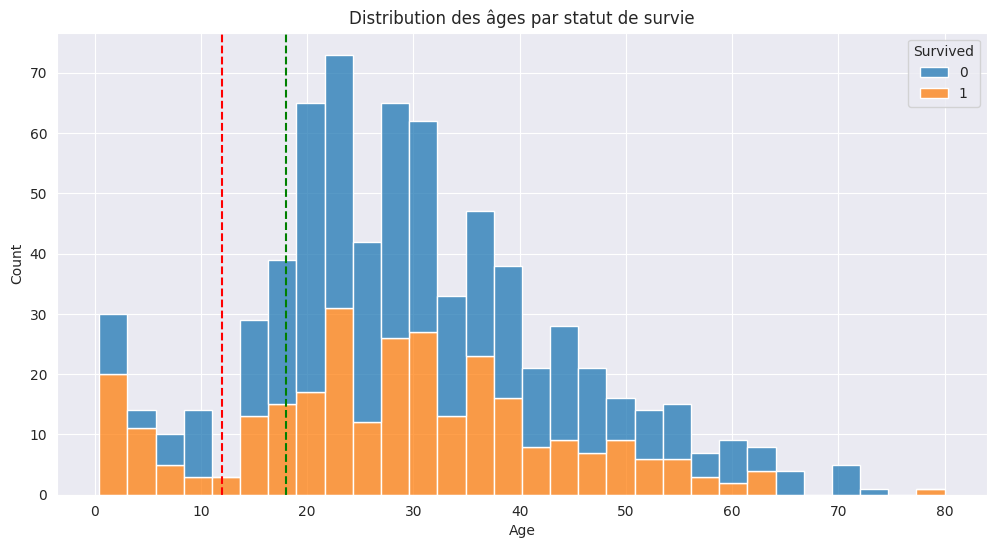

In [32]:
# Let's see how age is distributed
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(data=df_train, x='Age', hue='Survived', multiple='stack', bins=30)
plt.axvline(x=12, color='r', linestyle='--')
plt.axvline(x=18, color='g', linestyle='--')
plt.title('Distribution des âges par statut de survie')
plt.show()

We can see that there is a majority of adults.
The threshold is arbitrary indeed, but intuitively a person is child is he is less than 12.

In [33]:
def categorize_age(X):
    X_copy = X.copy()


    bins = [0, 12, 18, 35, 50]
    labels = [0, 1, 2, 3]

    X_copy['AgeCategory'] = pd.cut(
        X_copy['Age'],
        bins=bins,
        labels=labels
    )

    X_copy['AgeCategory'] = X_copy['AgeCategory'].fillna(2) # Where supposing here that if we don't the age; it must be an adult
    return X_copy[['AgeCategory']]

- As I did before, we're trying to assemble the feature of families, in order to see if it helps, different size of families, kids with families etc.

In [34]:
def create_family_features(X):
    X_copy = X.copy()

    X_copy['FamilySize'] = X_copy['SibSp'] + X_copy['Parch'] + 1

    X_copy['IsAlone'] = (X_copy['FamilySize'] == 1).astype(int)

    X_copy['FamilyCategory'] = pd.cut(
        X_copy['FamilySize'],
        bins=[0, 1, 4, float('inf')],
        labels=[0, 1, 2]
    ).astype(int)
    return X_copy[['FamilyCategory', 'IsAlone', 'FamilyCategory']]

- This is a bit of risk, but because Fare and classes are very correlated, So first We will first normalize the tariff to the size of the family, and then next combine those two variable.

In [35]:
def process_fare_class(X):
    X_copy = X.copy()

    X_copy['FarePerPerson'] = X_copy['Fare'] / (X_copy['SibSp'] + X_copy['Parch'] + 1)

    X_copy['FareClass'] = X_copy['Pclass'].astype(str)+ '_' + pd.qcut(
        X_copy['FarePerPerson'].fillna(X_copy['FarePerPerson'].median()),
        4,
        labels=[0, 1, 2, 3]
    ).astype(str)
    return X_copy[['FareClass']]

In [36]:
title_transformer = FunctionTransformer(extract_title)
family_transformer = FunctionTransformer(create_family_features)
age_transformer = FunctionTransformer(categorize_age)
fare_transformer = FunctionTransformer(process_fare_class)


In [37]:
preprocessor = ColumnTransformer([
    ('title', title_transformer, ['Name']),
    ('family', family_transformer, ['SibSp', 'Parch']),
    ('age_cat', age_transformer, ['Age']),
    ('fare_class', fare_transformer, ['Fare', 'Pclass', 'SibSp', 'Parch']),
    ('categorical', OneHotEncoder(drop='first'), ['Sex', 'Embarked']),
], remainder='drop')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        max_depth=4,
        learning_rate=0.05,
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        reg_alpha=1,
        reg_lambda=1
    ))
])



In [38]:
scores = cross_val_score(pipeline, df_train, df_train['Survived'], cv=5, scoring='accuracy')
print(f"Accuracy moyenne: {scores.mean():.4f}")
print(f"Écart-type: {scores.std():.4f}")

Accuracy moyenne: 0.8283
Écart-type: 0.0212


In [39]:
pipeline.fit(df_train, df_train['Survived'])


predictions = pipeline.predict(df_test)


submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': predictions
})
submission.to_csv('engineered_xgb_submission.csv', index=False)

Engineering analysis:
With my first attempt, i only tried to OneHotEncode sex and port where the passenger took the titanic.
But what i showed in my model is that there is more categorical variable than it seems, "Woman and children first" is an interesting sentence for this exercice, instead of having different ages, we just need to create different class to point out children, young and the other, because it's feature that actually play a role, as shown in my first analysis.

# Conclusion :
We thought that bringing a bazooka to a fight of sword will settled quickly but in reality, the sword team was lighter and quicker, we got slain.

But seriously, this is a proof of overfitting a problem, our solution from 4h ago beat all the attempt we did after because we tried to analyse and feature engineer too much, it leads us to just stagnate, or maybe the tool we used before were just to powerful, lighter so more suited to a simple problem as Titanic.

In [40]:
# Let's see if SVM will do better
from sklearn.svm import SVC

In [41]:


from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)



In [42]:

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])
scoring = 'accuracy'
score = cross_val_score(pipeline, df_train, df_train["Survived"], cv=k_fold, n_jobs=1, scoring=scoring)
print(score)
round(np.mean(score)*100,2)
# It's clearly bad, but I have to try.

[0.76666667 0.73033708 0.6741573  0.62921348 0.68539326 0.78651685
 0.71910112 0.71910112 0.76404494 0.64044944]


np.float64(71.15)